# ⚽ Football Analytics with Python
## Chapter 5 — Line Charts and Career Arcs

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-05-Line-Charts-Career-Arcs/Chapter_05_Line_Charts_Career_Arcs.ipynb)

---

A career arc is the most honest chart in football analytics. It shows not just
where a player is now but where they have been, how they got there, and —
if you read it carefully — where they might be going.

This chapter teaches the full career arc technique: smoothed line charts using
cubic spline interpolation, multi-player overlays, peak annotations, and how to
make a line chart that tells a story about time rather than just showing it.

### What You Will Build

1. **A basic line chart** — single player, GI/90 by season
2. **A smoothed line chart** — cubic spline interpolation
3. **A multi-player career arc** — 4 players overlaid on one chart
4. **An annotated arc** — peak seasons, turning points, callout boxes
5. **The `build_career_arc()` template** — one function, any players

### The Key Technique: Cubic Spline Interpolation

Raw career data has a problem: it connects discrete seasonal points with straight
lines, creating a jagged zigzag that is hard to read at a glance. Cubic spline
interpolation fits a smooth curve through the same points — mathematically exact
at each season, but beautifully smooth between them.

```python
from scipy.interpolate import make_interp_spline
xs = np.linspace(x.min(), x.max(), 300)
ys = make_interp_spline(x, y, k=3)(xs)
```

That is all it takes. Four lines of code separate a jagged line from a
professional career arc.

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

In [1]:
!pip install pandas matplotlib numpy scipy --quiet
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
print("✓ Ready.")

✓ Ready.


In [1]:
BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; ORANGE='#FF9800'; RED='#e63946'
TIER_COLORS={'Elite':GREEN,'Above Average':YELLOW,'Average':ORANGE,'Below Average':RED}
PLAYER_COLORS={
    'Marcus Silva':'#3498DB','Lucas Ferreira':'#2ecc71',
    'James Thornton':'#e74c3c','Diego Varela':'#9B59B6',
    'Amir Hassan':'#FF9800','Kai Becker':'#00BCD4',
    'Tom Wheeler':'#F06292','Sam Okafor':'#80CBC4',
    'Elena Rossi':'#FFD54F','Carlos Mendez':'#CE93D8',
    'Jin Park':'#A5D6A7',
}
def style_axis(ax,theme='dark',xlabel=None,ylabel=None,title=None,subtitle=None):
    bg=BG if theme=='dark' else '#f8f9fa'
    tc=WHITE if theme=='dark' else '#1a1a2e'
    gc=WHITE if theme=='dark' else '#cccccc'
    sc=GRAY  if theme=='dark' else '#888888'
    ax.set_facecolor(bg)
    ax.spines['bottom'].set_color(sc); ax.spines['left'].set_color(sc)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(colors=tc,labelsize=10)
    ax.grid(True,alpha=0.07,color=gc,linewidth=0.8)
    if xlabel: ax.set_xlabel(xlabel,color=tc,fontsize=11,labelpad=8)
    if ylabel: ax.set_ylabel(ylabel,color=tc,fontsize=11,labelpad=8)
    if title and subtitle:
        ax.set_title(title+'\n'+subtitle,color=tc,fontsize=13,fontweight='bold',pad=15,linespacing=1.6)
    elif title: ax.set_title(title,color=tc,fontsize=13,fontweight='bold',pad=12)
    return ax
print("✓ Design system loaded.")

✓ Design system loaded.


---
## Part 1 — Loading the Career Data

In [1]:
df = pd.read_csv('data/chapter05_careers.csv')
players = df['player'].unique()
print(f"Players: {len(players)} | Seasons: {df['season'].nunique()}")
print()
# Seasons per player
for p in players:
    seasons = df[df['player']==p]['season'].tolist()
    print(f"  {p:<20} {len(seasons)} seasons: {seasons[0]} → {seasons[-1]}")

Players: 6 | Seasons: 16

  Marcus Silva         6 seasons: 2019/20 → 2024/25
  Lucas Ferreira       7 seasons: 2018/19 → 2024/25
  James Thornton       3 seasons: 2022/23 → 2024/25
  Diego Varela         8 seasons: 2017/18 → 2024/25
  Amir Hassan          5 seasons: 2020/21 → 2024/25
  Elena Rossi          2 seasons: 2023/24 → 2024/25


---
## Part 2 — Step 1: Basic Line Chart (Single Player)

Always build simple before building complex. Here is Marcus Silva's
career in the most basic form possible — raw points connected by straight lines.

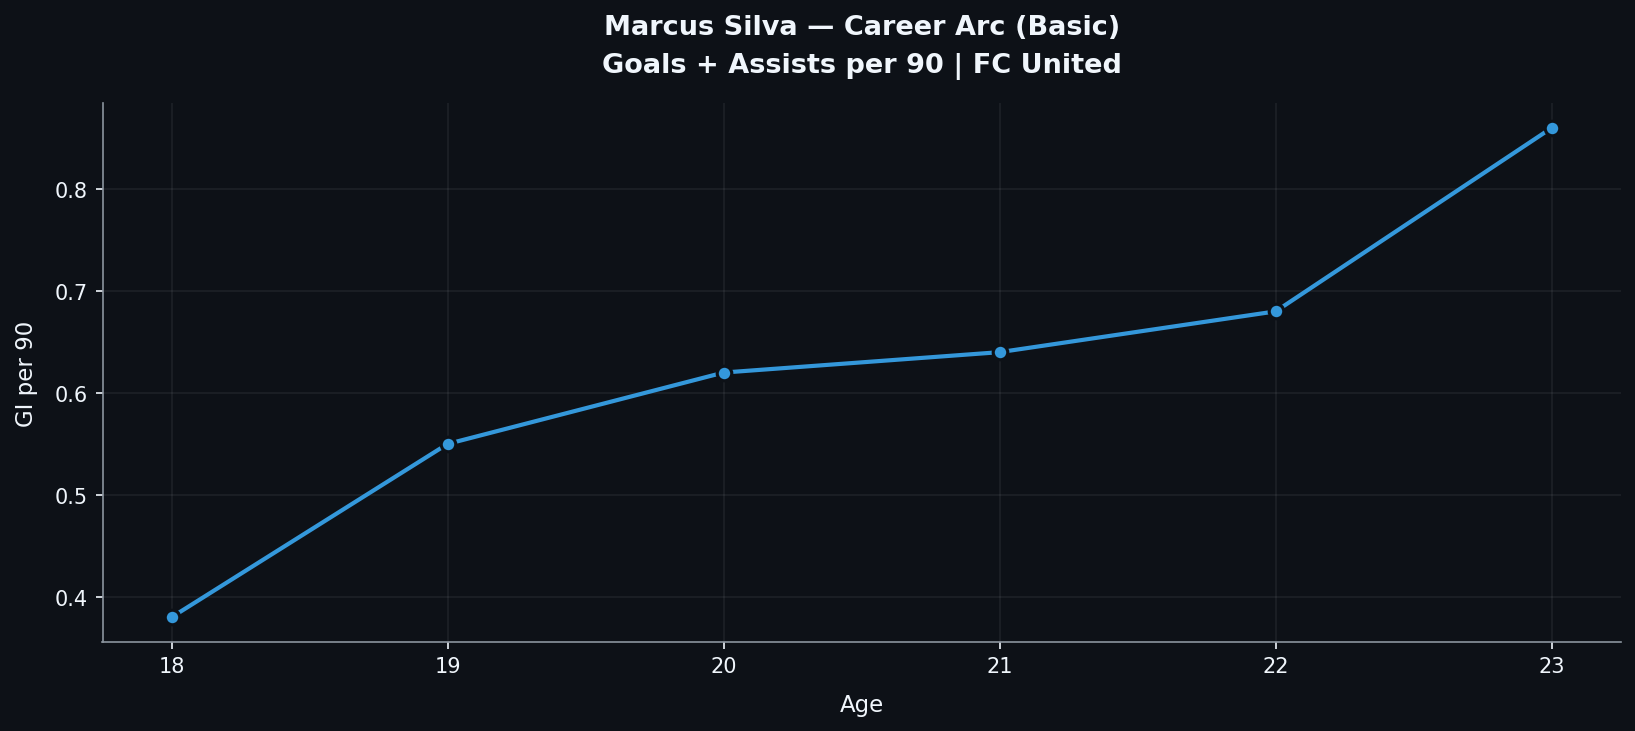

Basic line chart — raw points connected by straight lines.
Notice the zigzag between seasons. We fix this next.


In [1]:
marcus = df[df['player'] == 'Marcus Silva'].sort_values('age')

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)

ax.plot(marcus['age'], marcus['gi_per90'],
        color=PLAYER_COLORS['Marcus Silva'],
        linewidth=2, marker='o', markersize=7,
        markeredgecolor=BG, markeredgewidth=1.5)

style_axis(ax, xlabel='Age', ylabel='GI per 90',
           title='Marcus Silva — Career Arc (Basic)',
           subtitle='Goals + Assists per 90 | FC United')
plt.tight_layout()
plt.show()

print("Basic line chart — raw points connected by straight lines.")
print("Notice the zigzag between seasons. We fix this next.")

---
## Part 3 — Step 2: Cubic Spline Smoothing

The `make_interp_spline` function from scipy fits a smooth curve that passes
**exactly** through every data point but curves smoothly between them.

`k=3` means cubic (3rd-degree polynomial). This is the standard for career arcs
— smooth enough to be readable, faithful enough to the data to be honest.

**Important:** You need at least 4 data points for k=3 spline. For players with
fewer seasons, use `k=min(3, len(data)-1)` as a safe fallback.

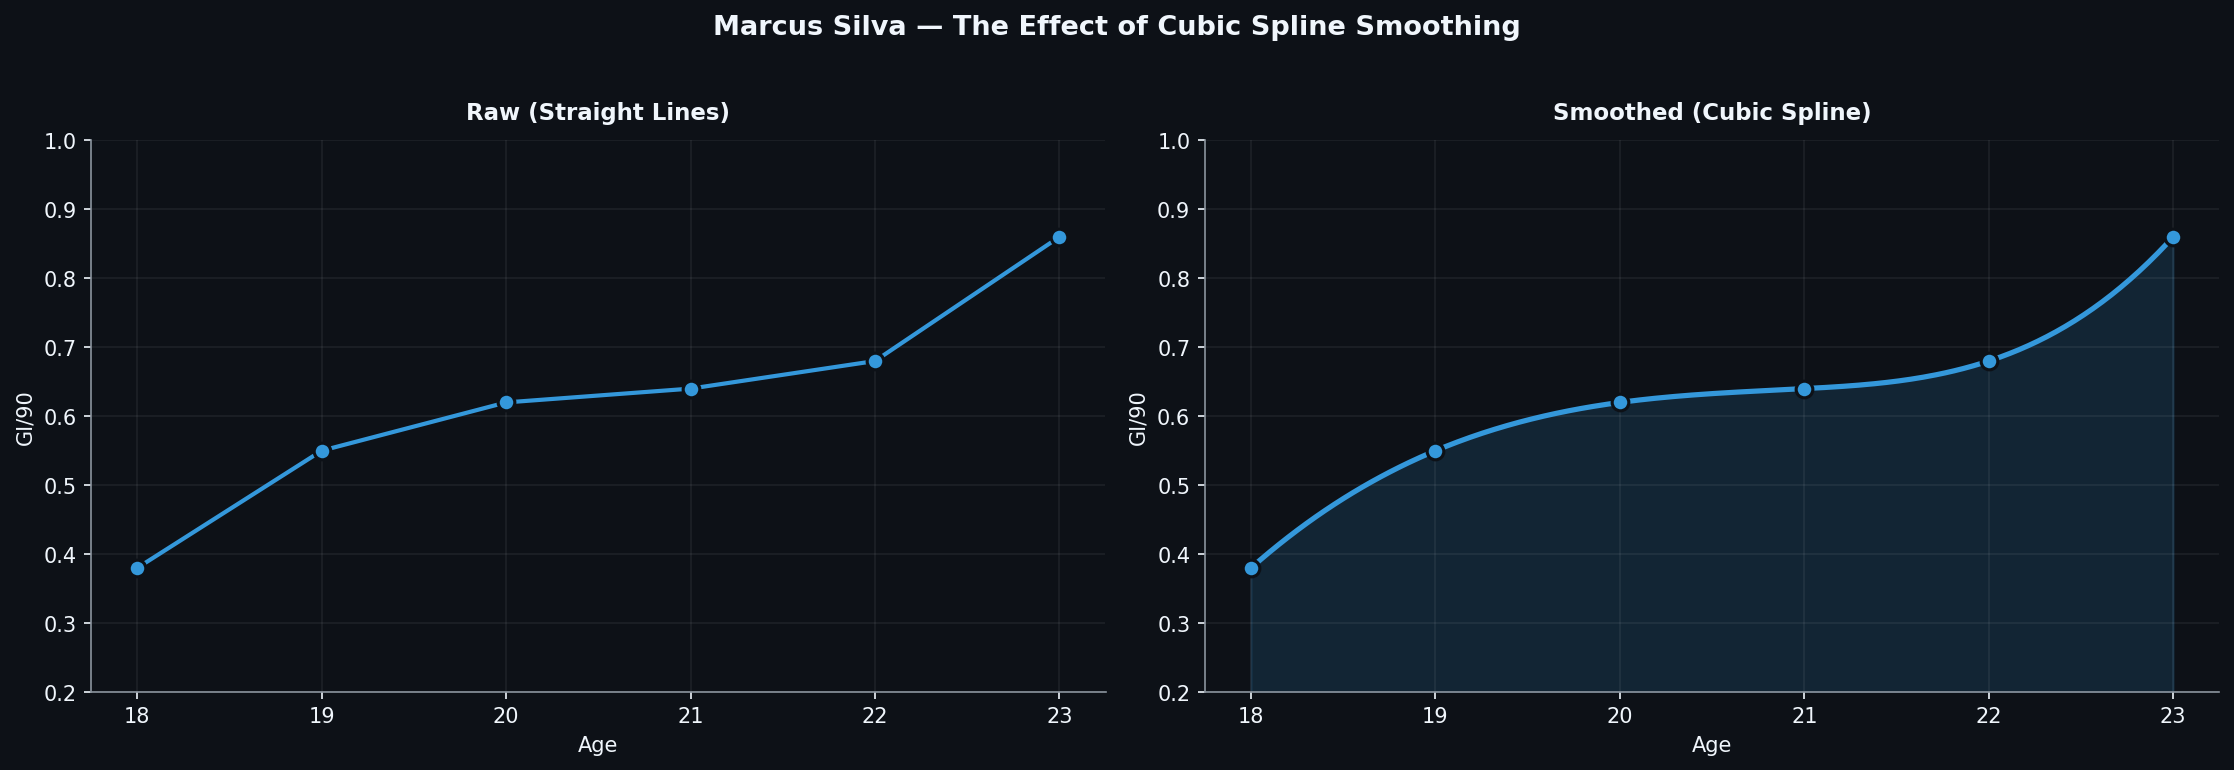

In [1]:
from scipy.interpolate import make_interp_spline

def smooth_career(x, y):
    """
    Apply cubic spline interpolation to a career arc.
    Returns 300 smoothly-spaced x,y points between the first and last season.

    Parameters: x = age values, y = stat values (lists or arrays)
    Returns:    xs, ys — smooth x and y arrays ready to plot
    """
    xs = np.linspace(min(x), max(x), 300)
    ys = make_interp_spline(x, y, k=min(3, len(x)-1))(xs)
    return xs, ys

marcus = df[df['player'] == 'Marcus Silva'].sort_values('age')

# Side by side: raw vs smoothed
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(BG)
c = PLAYER_COLORS['Marcus Silva']

# Raw
ax1.set_facecolor(BG)
ax1.plot(marcus['age'], marcus['gi_per90'], color=c, linewidth=2)
ax1.plot(marcus['age'], marcus['gi_per90'], 'o', color=c,
         markersize=8, markeredgecolor=BG, markeredgewidth=1.5, zorder=5)

# Smoothed
ax2.set_facecolor(BG)
xs, ys = smooth_career(marcus['age'].values, marcus['gi_per90'].values)
ax2.plot(xs, ys, color=c, linewidth=2.5)
ax2.fill_between(xs, ys, alpha=0.15, color=c)
ax2.plot(marcus['age'], marcus['gi_per90'], 'o', color=c,
         markersize=8, markeredgecolor=BG, markeredgewidth=1.5, zorder=5)

for ax, title in [(ax1, 'Raw (Straight Lines)'), (ax2, 'Smoothed (Cubic Spline)')]:
    ax.spines['bottom'].set_color(GRAY); ax.spines['left'].set_color(GRAY)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(colors=WHITE)
    ax.grid(True, alpha=0.07, color=WHITE)
    ax.set_xlabel('Age', color=WHITE); ax.set_ylabel('GI/90', color=WHITE)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylim(0.2, 1.0)

fig.suptitle('Marcus Silva — Effect of Cubic Spline Smoothing',
             color=WHITE, fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 4 — Step 3: Multi-Player Career Arc

Overlaying multiple players on one chart reveals the most interesting
analytical story — who peaked earliest, who is still rising, who has plateaued.

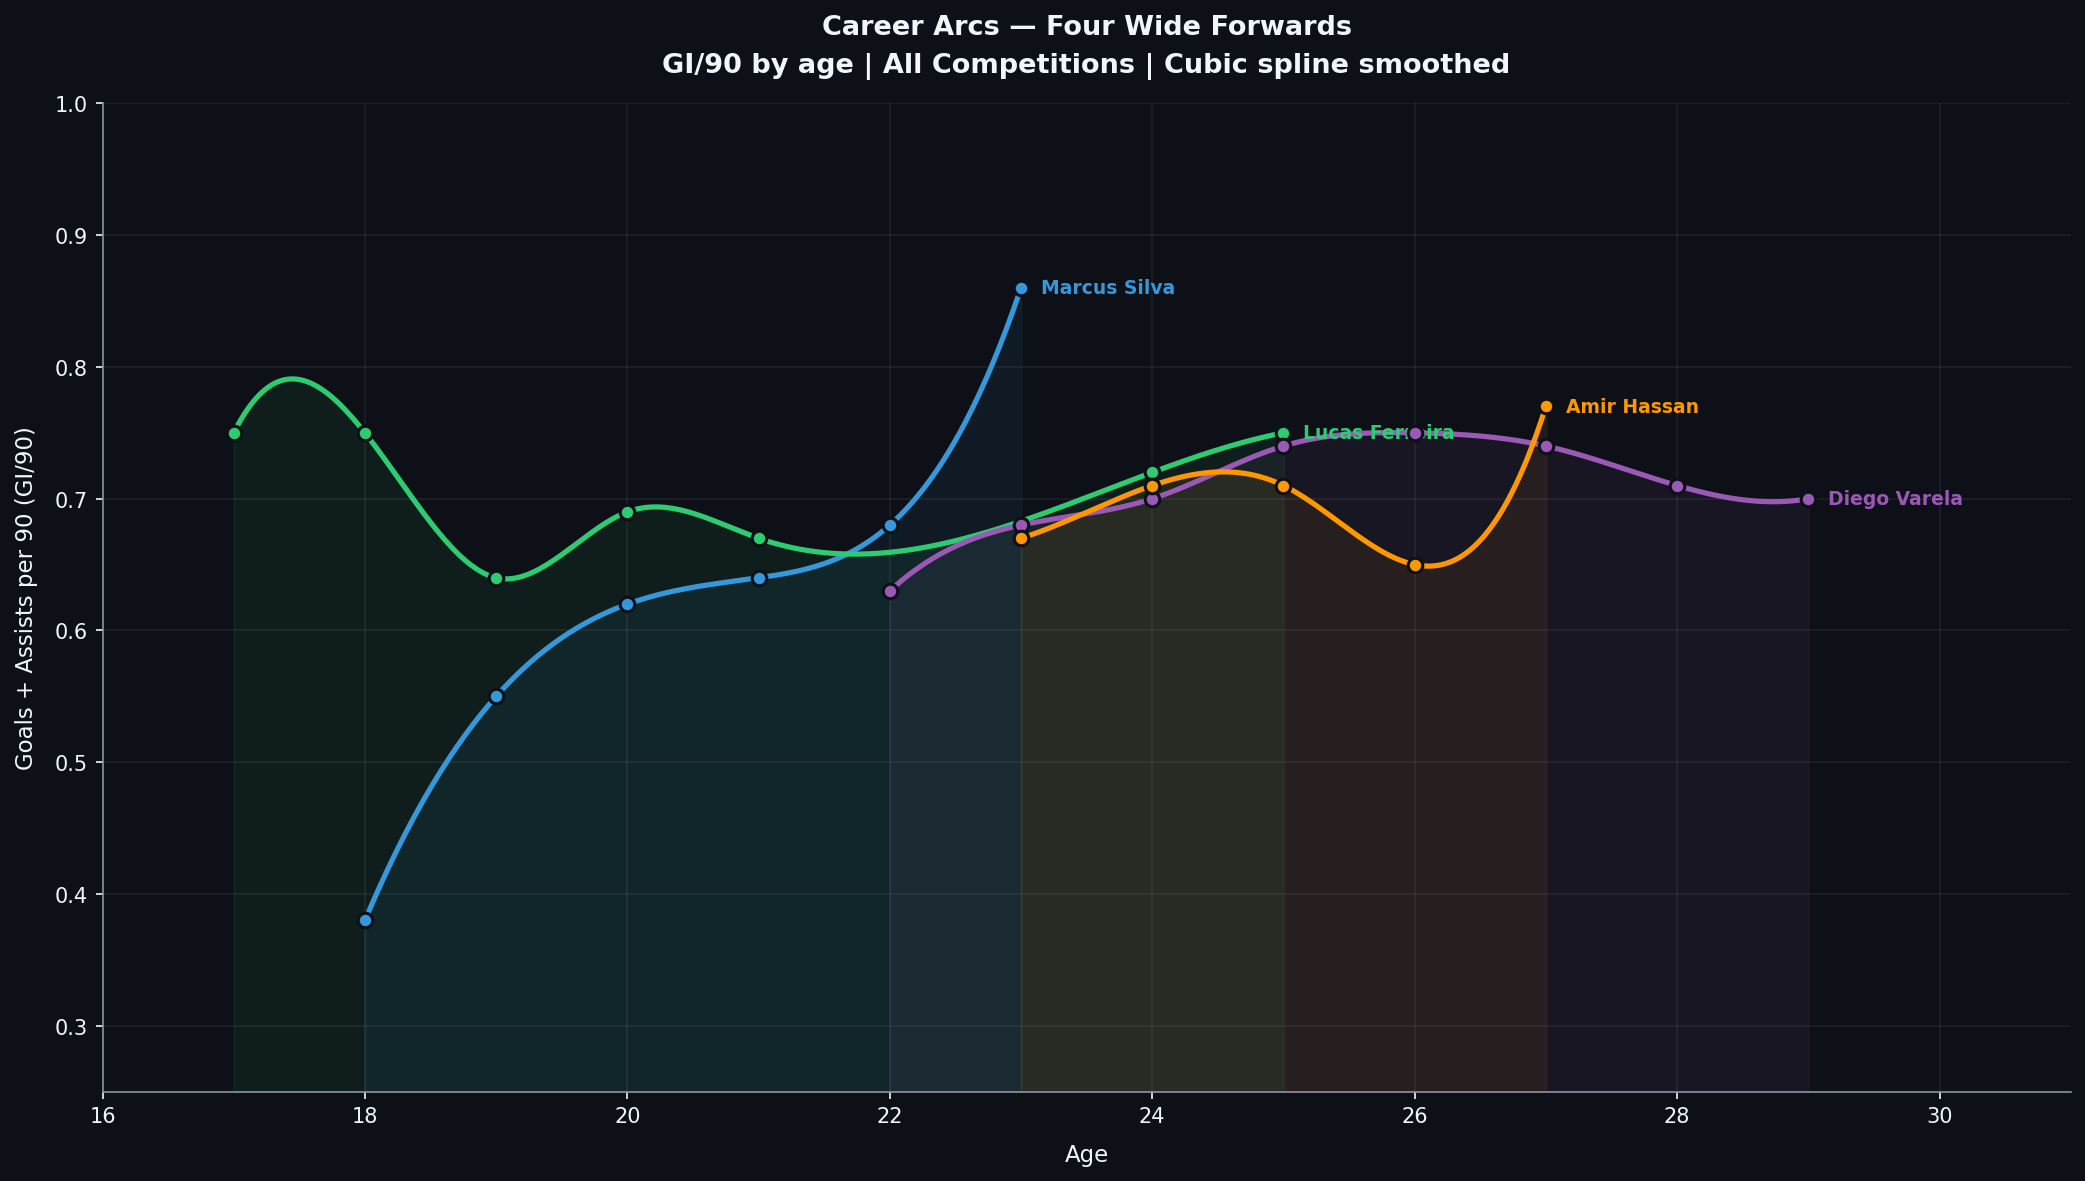

In [1]:
focus_players = ['Marcus Silva', 'Lucas Ferreira', 'Diego Varela', 'Amir Hassan']

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(BG)

for player in focus_players:
    player_data = df[df['player'] == player].sort_values('age')
    if len(player_data) < 2: continue
    c = PLAYER_COLORS[player]

    # Smooth the career arc
    xs, ys = smooth_career(player_data['age'].values,
                            player_data['gi_per90'].values)

    # Smoothed line + fill
    ax.plot(xs, ys, color=c, linewidth=2.5, label=player)
    ax.fill_between(xs, ys, alpha=0.07, color=c)

    # Raw season dots
    ax.plot(player_data['age'], player_data['gi_per90'],
            'o', color=c, markersize=7,
            markeredgecolor=BG, markeredgewidth=1.5, zorder=5)

    # Player name label at the end of their line
    last_season = player_data.iloc[-1]
    ax.annotate(player,
                xy=(last_season['age'], last_season['gi_per90']),
                xytext=(last_season['age'] + 0.15, last_season['gi_per90']),
                color=c, fontsize=9, fontweight='bold', va='center')

style_axis(ax,
    xlabel='Age',
    ylabel='Goals + Assists per 90 (GI/90)',
    title='Career Arcs — Four Wide Forwards',
    subtitle='GI/90 by age | All Competitions | Cubic spline smoothed')

ax.set_xlim(16, 31)
ax.set_ylim(0.25, 1.0)
plt.tight_layout()
plt.show()

### Reading the Multi-Player Arc

**Marcus Silva** (blue): the steepest upward trajectory in the group.
Six seasons of consistent growth, accelerating sharply in 24/25.
At 23, his arc is still rising — no sign of a peak yet.

**Diego Varela** (purple): a textbook peak-and-plateau pattern. He peaked at
25–26 (around 0.75 GI/90) and has been declining gradually since. At 29, the
curve is flattening toward a level he may sustain for 2–3 more seasons.

**Lucas Ferreira** (green): high but flat. His career arc shows very little
growth — he entered professional football at an already-high level (0.75 at 17)
and has maintained it. Remarkably consistent, but not developing upward.

**Amir Hassan** (orange): a V-shape with a dip in 23/24 followed by his best
season in 24/25. This is the pattern of a player who had a difficult year —
perhaps injury, perhaps a system change — and then bounced back stronger.

These four patterns — rising, peaking-and-declining, flat-and-consistent,
V-shaped recovery — are the four archetypes you will see in most career arc analyses.

---

## Part 5 — The `build_career_arc()` Template

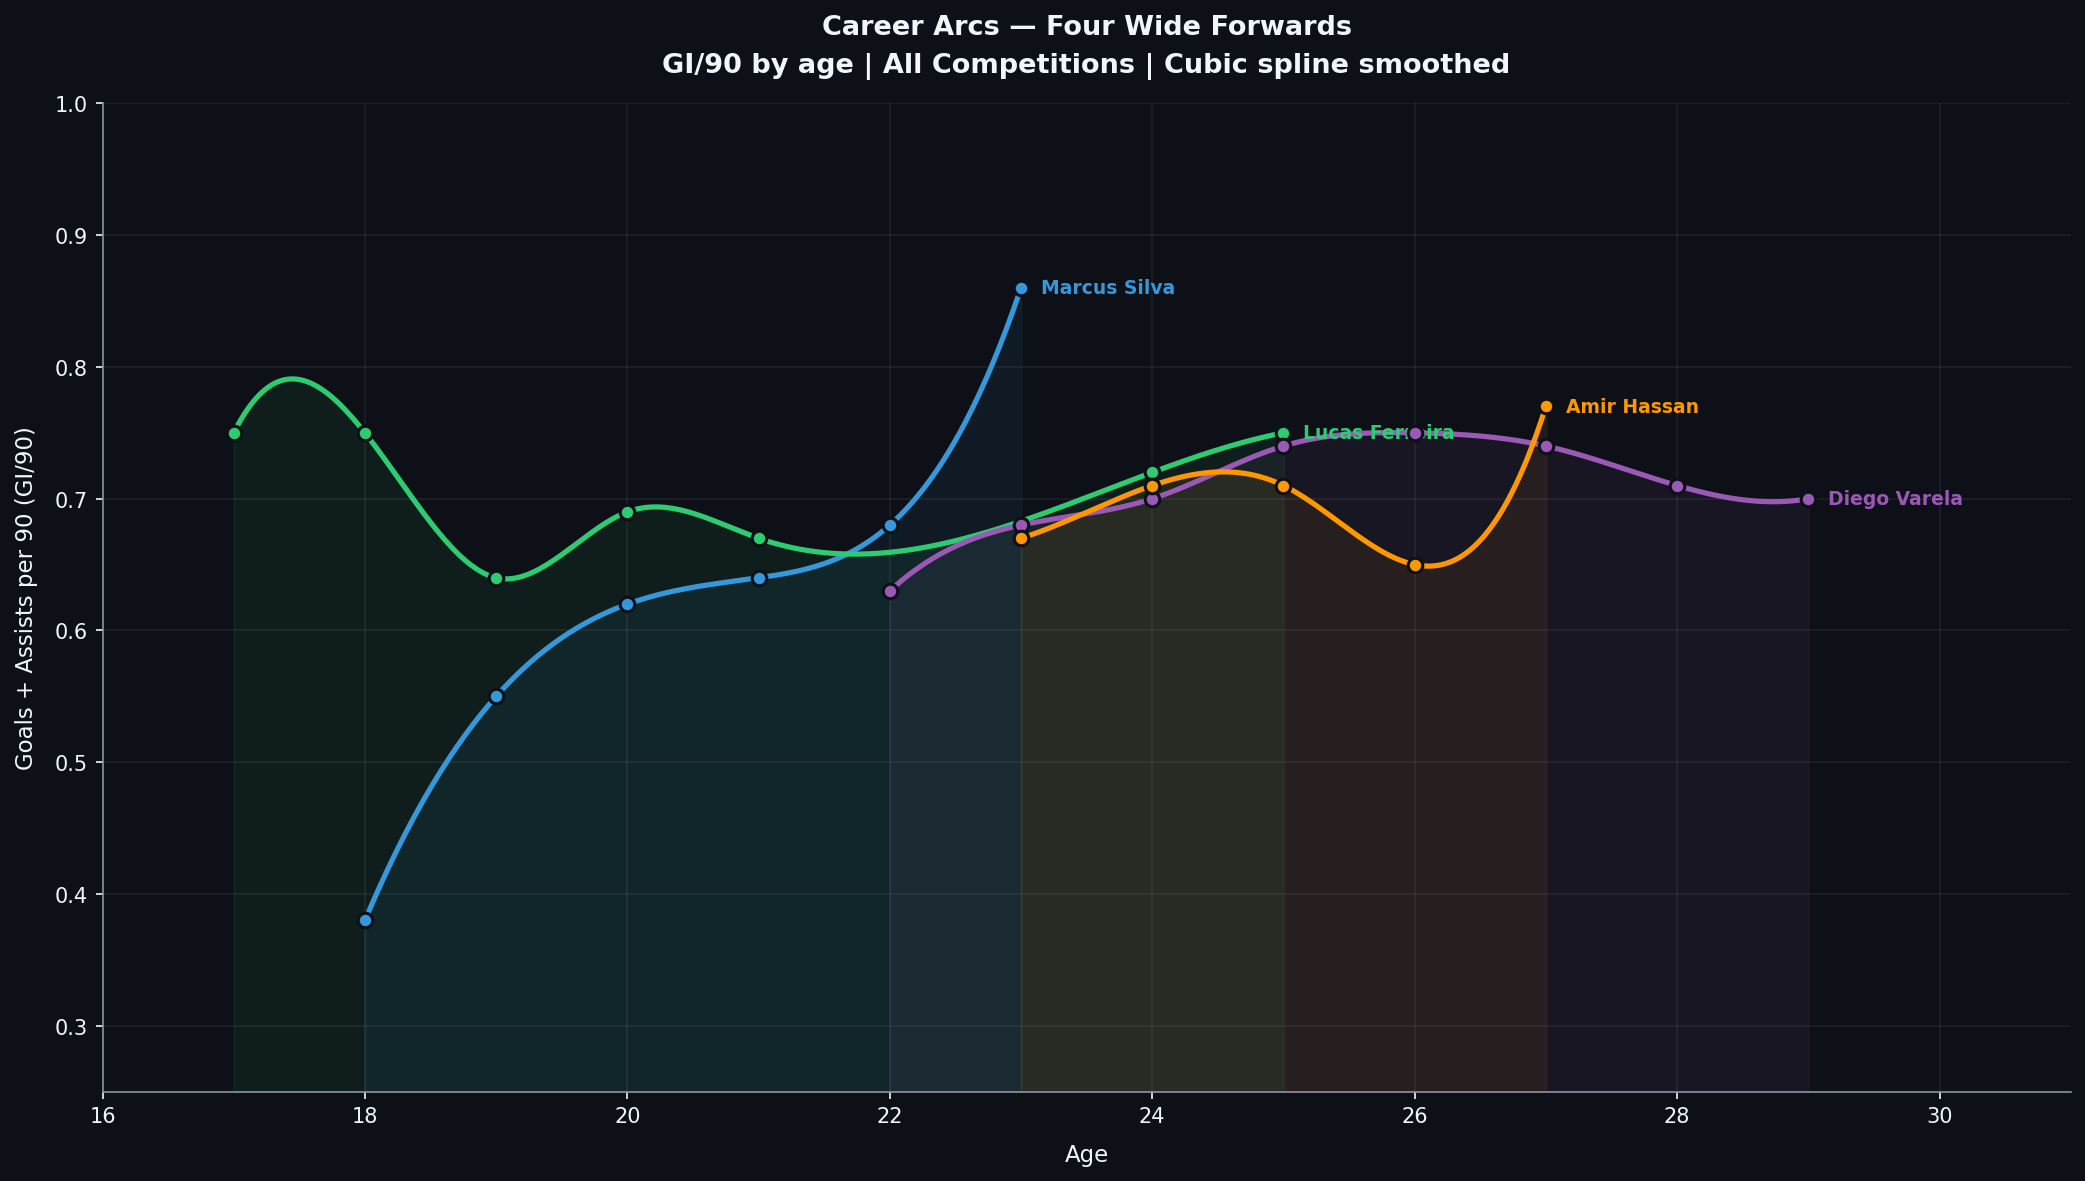

✓ build_career_arc() template defined and working.
  Change 'players', 'metric', 'title' — everything else is handled.


In [1]:
def build_career_arc(df, players, metric='gi_per90',
                     xlabel='Age', title='Career Arc',
                     subtitle='', xlim=None, ylim=None,
                     figsize=(14, 8)):
    """
    Build a smoothed multi-player career arc chart.

    Parameters
    ----------
    df       : DataFrame with columns: player, age, and the metric column
    players  : list[str] — player names to include
    metric   : str — column to plot on Y axis (default: 'gi_per90')
    xlabel   : str — x-axis label
    title    : str — chart title
    subtitle : str — chart subtitle
    xlim     : tuple (min, max) — x-axis range, auto if None
    ylim     : tuple (min, max) — y-axis range, auto if None
    figsize  : tuple — figure size

    Returns
    -------
    fig, ax — matplotlib figure and axes (so you can add more annotations)

    Usage
    -----
    fig, ax = build_career_arc(
        df, ['Marcus Silva', 'Diego Varela'],
        metric='gi_per90',
        title='Career Arcs', subtitle='GI/90 by age'
    )
    plt.show()
    """
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG)

    for player in players:
        pdata = df[df['player'] == player].sort_values('age')
        if len(pdata) < 2: continue
        c = PLAYER_COLORS.get(player, GRAY)

        # Smooth
        xs, ys = smooth_career(pdata['age'].values, pdata[metric].values)

        ax.plot(xs, ys, color=c, linewidth=2.5)
        ax.fill_between(xs, ys, alpha=0.08, color=c)
        ax.plot(pdata['age'], pdata[metric], 'o',
                color=c, markersize=7,
                markeredgecolor=BG, markeredgewidth=1.5, zorder=5)

        last = pdata.iloc[-1]
        ax.annotate(player,
                    xy=(last['age'], last[metric]),
                    xytext=(last['age'] + 0.2, last[metric]),
                    color=c, fontsize=9, fontweight='bold', va='center')

    style_axis(ax, xlabel=xlabel, ylabel=metric.replace('_',' ').title(),
               title=title, subtitle=subtitle)

    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)

    return fig, ax


# ── Test the template ─────────────────────────────────────────────────────
fig, ax = build_career_arc(
    df=df,
    players=['Marcus Silva', 'Diego Varela', 'Amir Hassan'],
    metric='gi_per90',
    title='Career Arcs — Three Profiles',
    subtitle='Rising · Declining · Recovery — GI/90 by age',
    xlim=(17, 31), ylim=(0.3, 1.0)
)
plt.tight_layout()
plt.show()

print("✓ build_career_arc() template defined and working.")
print("  Change 'players', 'metric', 'title' — everything else is handled.")

---
## Part 6 — Exercises

### Exercise 1 — Change the Metric (Easy)
Call `build_career_arc()` with `metric='pass_accuracy_pct'` instead of `gi_per90`.
Which player has improved their passing accuracy the most across their career?

### Exercise 2 — Annotate a Peak (Medium)
Find Marcus Silva's peak season (highest GI/90 row) and add an annotation to the chart:
```python
peak = marcus[marcus['gi_per90'] == marcus['gi_per90'].max()].iloc[0]
ax.annotate('Peak season', xy=(peak['age'], peak['gi_per90']),
            xytext=(peak['age']-1, peak['gi_per90']+0.05),
            color=GOLD, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.2))
```

### Exercise 3 — Predict the Trajectory (Hard)
Using Marcus Silva's arc, extend the smooth curve 2 seasons forward by
extrapolating the spline. What GI/90 does the model predict at age 25?
Add a dashed line showing the predicted portion.

**Caution:** Extrapolation beyond the data range is statistically unreliable.
Add a text label: "Projected (extrapolated — treat with caution)".

---

## Chapter Summary

| Concept | What You Learned |
|---------|-----------------|
| Cubic spline | Smooth curve through exact data points — `make_interp_spline(x,y,k=3)` |
| `smooth_career()` | Reusable smoothing function — 4 lines |
| `build_career_arc()` | Full template — any players, any metric |
| Career archetypes | Rising / Plateau / Peaking / V-shaped recovery |
| `fill_between()` | Shaded area under line for visual weight |
| End-of-line labels | Annotate the last point with the player name |

---
## Up Next — Chapter 6: Bar Charts for Comparison

*© 2026 HackrLife Media LLC · BarcaFutbol Analytics Course*